<a href="https://colab.research.google.com/github/00015775/learning-lab/blob/learn%2Fpytorch/pytorch/notebooks/02_youtube_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Saving PyTorch model

In [1]:
# stopped at 7:22

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() \
                      else "mps" if torch.backends.mps.is_available()\
                      else "cpu")

In [4]:
import numpy as np

def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.

    Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)
    """
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

In [5]:
from pathlib import Path

torch.manual_seed(42)

SAVE_MODEL_DIR = Path("./models")
SAVE_MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "model.pth"
MODEL_SAVE_PATH = SAVE_MODEL_DIR / MODEL_NAME # forward slash like unix

model = nn.Linear(1,1) # one neuron for each layer
model.to("cpu") # make sure save on CPU for OS agnostic purposes

torch.save(obj=model.state_dict(), f=MODEL_SAVE_PATH)

In [6]:
model.state_dict() # weights and biases are randomly initialized

OrderedDict([('weight', tensor([[0.7645]])), ('bias', tensor([0.8300]))])

In [7]:
!ls -l ./models/ && echo && du -h ./models/

total 4
-rw-r--r-- 1 root root 1877 Jan 30 04:27 model.pth

8.0K	./models/


In [8]:
# if saved on GPU, it will try to load on GPU, but if
# other computer does not have a GPU, then it will throw an error
# make sure to make it OS agnostic by saving on CPU

In [9]:
# create an instance of the same model in order for architeture to match
# and be able to load into it
loaded_model_0 = nn.Linear(1,1)

loaded_model_0

Linear(in_features=1, out_features=1, bias=True)

In [10]:
print(MODEL_SAVE_PATH)

models/model.pth


In [11]:
loaded_model_0.load_state_dict(torch.load(MODEL_SAVE_PATH))

<All keys matched successfully>

In [12]:
model.state_dict()

OrderedDict([('weight', tensor([[0.7645]])), ('bias', tensor([0.8300]))])

In [13]:
loaded_model_0.state_dict()

OrderedDict([('weight', tensor([[0.7645]])), ('bias', tensor([0.8300]))])

In [14]:
model.state_dict() == loaded_model_0.state_dict()

True

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:132: UserWarning: Using a target size (torch.Size([5, 1])) that is different to the input size (torch.Size([4, 5, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


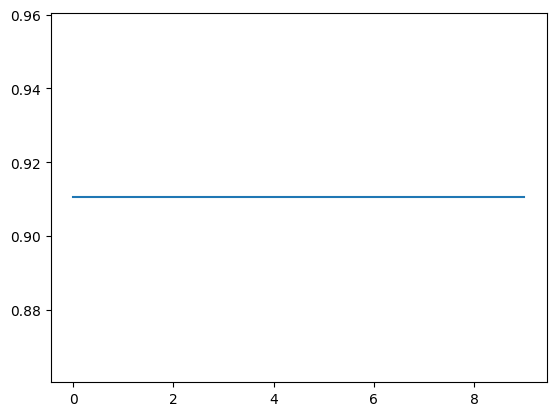

In [15]:
import matplotlib.pyplot as plt


x_test = torch.randn(4,5,1)
y_test = x_test[-1]
loaded_model_0.to(device)
loaded_model_0.eval()
test_loss = []
loss_fn = nn.L1Loss()

with torch.inference_mode():
  for i in range(10):
    output = loaded_model_0(x_test)
    loss = loss_fn(output, y_test)
    test_loss.append(loss.item())

plt.plot(test_loss)
plt.show()

In [16]:
torch.__version__

'2.9.0+cpu'

In [17]:
weight = 0.7
bias = 0.3

X = torch.arange(0, 1, 0.02).unsqueeze(dim=1)
y = weight * X + bias

X.shape, y.shape

(torch.Size([50, 1]), torch.Size([50, 1]))

In [18]:
linear_model = nn.Linear(1,1)

print(linear_model.state_dict())

OrderedDict({'weight': tensor([[0.2687]]), 'bias': tensor([-0.2712])})


In [19]:
# stopped at 9:00

## NN

In [20]:
import sklearn
from sklearn.datasets import make_circles

In [21]:
n_samples = 1000

X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

In [22]:
X.shape, y.shape # (1000=examples, 2=features)

((1000, 2), (1000,))

In [23]:
len(X), len(y)

(1000, 1000)

In [24]:
type(X), type(y)

(numpy.ndarray, numpy.ndarray)

In [25]:
display(X[:5], y[:5])

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       [-0.39373073,  0.69288277],
       [ 0.44220765, -0.89672343]])

array([1, 1, 1, 1, 0])

In [26]:
y # binary classification

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,

In [27]:
X # input features

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [28]:
import pandas as pd

circles = pd.DataFrame({"X1": X[:, 0],  # first column
                        "X2": X[:, 1],  # second column
                        "label": y})    # target label

In [29]:
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [30]:
len(circles) # 1000 rows/examples/instances

1000

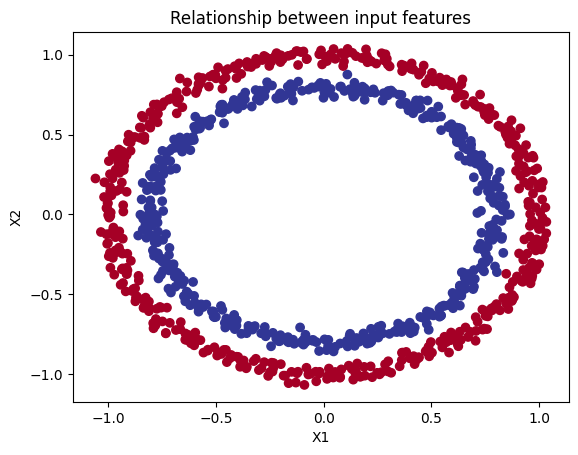

In [31]:
import matplotlib.pyplot as plt

plt.scatter(x=X[:, 0], # first column
            y=X[:, 1], # second column
            c=y,
            cmap=plt.cm.RdYlBu)

plt.xlabel('X1')
plt.ylabel('X2')
plt.title("Relationship between input features")
plt.show()

# relationship between input features

In [32]:
circles.describe()

,X1,X2,label
count,1000.000000,1000.000000,1000.00000
mean,-0.000448,-0.000804,0.50000
std,0.639837,0.641156,0.50025
min,-1.059502,-1.067768,0.00000
25%,-0.619251,-0.612176,0.00000
50%,0.008762,-0.003949,0.50000
75%,0.621933,0.624822,1.00000
max,1.033712,1.036004,1.00000


## Check input and output shapes

In [33]:
circles["X1"].shape, circles["X2"].shape, circles["label"].shape

((1000,), (1000,), (1000,))

In [34]:
X_sample = X[0] # first row
y_sample = y[0] # first row

print(f"one sample for X={X_sample}, shape={X_sample.shape}")
print(f"one sample for y={y_sample}, shape={y_sample.shape}")

one sample for X=[0.75424625 0.23148074], shape=(2,)
one sample for y=1, shape=()


## Turn data into Tensors

In [35]:
import torch
torch.__version__

'2.9.0+cpu'

In [36]:
type(X), type(y), X.dtype, y.dtype

(numpy.ndarray, numpy.ndarray, dtype('float64'), dtype('int64'))

In [37]:
X = torch.from_numpy(X).type(torch.float32)
y = torch.from_numpy(y).type(torch.float32)

In [38]:
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [39]:
X.dtype, y.dtype

(torch.float32, torch.float32)

In [40]:
type(X), type(y)

(torch.Tensor, torch.Tensor)

# Splitting dataset

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2, # 80% for train
                                                    shuffle=True,
                                                    random_state=42)


In [42]:
len(X_train), len(X_test)

(800, 200)

In [43]:
len(y_train), len(y_test)

(800, 200)

In [44]:
X_train.shape, X_test.shape

(torch.Size([800, 2]), torch.Size([200, 2]))

In [45]:
y_train.shape, y_test.shape

(torch.Size([800]), torch.Size([200]))

In [46]:
# stoped at 9:22

## Building a model

In [47]:
import torch
import torch.nn as nn


device = torch.device("cuda" if torch.cuda.is_available() else\
                      "mps" if torch.backends.mps.is_available() else\
                      "cpu")

device

device(type='cpu')

In [48]:
X_train.device, y_train.device

(device(type='cpu'), device(type='cpu'))

In [49]:
!pip install torchviz

In [50]:
from torchviz import make_dot
import matplotlib.image as mpimg

In [51]:
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=5)
    self.layer_2 = nn.Linear(in_features=5, out_features=1) # treat as output layer for now


  def forward(self, x):
    return self.layer_2(self.layer_1(x))


model_0 = CircleModelV0().to(device)

model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [52]:
dummy_input = torch.randn(1000, 2)

outputing = model_0(dummy_input)

dot = make_dot(outputing, params=dict(model_0.named_parameters()))
dot.render("model_0_diagram", format="png")

'model_0_diagram.png'

In [53]:
next(model_0.parameters()).device

device(type='cpu')

In [54]:
from collections import OrderedDict

class CircleModelSeq(nn.Module):
  def __init__(self):
    super().__init__()
    self.two_linear_layers = nn.Sequential(
        nn.Linear(2, 5),
        nn.Linear(5, 1)
    )


  def forward(self, x):
    return self.two_linear_layers(x)


model_0 = CircleModelSeq().to(device)

model_0

CircleModelSeq(
  (two_linear_layers): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): Linear(in_features=5, out_features=1, bias=True)
  )
)

In [55]:
model_0.state_dict()

OrderedDict([('two_linear_layers.0.weight',
              tensor([[-0.1945,  0.5406],
                      [ 0.0472,  0.5164],
                      [-0.4924,  0.2829],
                      [ 0.0843, -0.3537],
                      [ 0.3505, -0.6958]])),
             ('two_linear_layers.0.bias',
              tensor([0.5717, 0.0570, 0.0683, 0.3270, 0.0587])),
             ('two_linear_layers.1.weight',
              tensor([[ 0.1917,  0.2845, -0.3490,  0.2959, -0.0670]])),
             ('two_linear_layers.1.bias', tensor([-0.1040]))])

In [56]:
for name, val in model_0.named_parameters():
  print(name, val.shape)

two_linear_layers.0.weight torch.Size([5, 2])
two_linear_layers.0.bias torch.Size([5])
two_linear_layers.1.weight torch.Size([1, 5])
two_linear_layers.1.bias torch.Size([1])


In [57]:
criterion = nn.L1Loss()

with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
  loss = criterion(untrained_preds, y_test)

print(loss)

tensor(0.5132)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:132: UserWarning: Using a target size (torch.Size([200])) that is different to the input size (torch.Size([200, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


In [58]:
untrained_preds.shape, X_test.shape, y_test.shape

(torch.Size([200, 1]), torch.Size([200, 2]), torch.Size([200]))

In [59]:
y_test[:10]

tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])

In [60]:
untrained_preds[:10]

tensor([[ 0.0987],
        [ 0.1831],
        [-0.0438],
        [ 0.1388],
        [ 0.0812],
        [ 0.1317],
        [ 0.2703],
        [ 0.2586],
        [-0.0488],
        [ 0.1902]])

## Loss function and optimizer

In [61]:
nn.Sequential(
    nn.Sigmoid(),
    nn.BCELoss() # binary cross-entropy
)

loss_fn = nn.BCEWithLogitsLoss() # nn.Sigmoid() + nn.BCELoss()

optimizer = torch.optim.SGD(model_0.parameters(),
                            lr=0.001)


In [62]:
model_0.state_dict()

OrderedDict([('two_linear_layers.0.weight',
              tensor([[-0.1945,  0.5406],
                      [ 0.0472,  0.5164],
                      [-0.4924,  0.2829],
                      [ 0.0843, -0.3537],
                      [ 0.3505, -0.6958]])),
             ('two_linear_layers.0.bias',
              tensor([0.5717, 0.0570, 0.0683, 0.3270, 0.0587])),
             ('two_linear_layers.1.weight',
              tensor([[ 0.1917,  0.2845, -0.3490,  0.2959, -0.0670]])),
             ('two_linear_layers.1.bias', tensor([-0.1040]))])

In [63]:
optimizer.state_dict()

{'state': {},
 'param_groups': [{'lr': 0.001,
   'momentum': 0,
   'dampening': 0,
   'weight_decay': 0,
   'nesterov': False,
   'maximize': False,
   'foreach': None,
   'differentiable': False,
   'fused': None,
   'params': [0, 1, 2, 3]}]}

In [64]:
# Accuracy: (TF + TN) / (TF + TN + FP + FN)

def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct/len(y_pred)) * 100
  return acc

In [65]:
# stopped at 10:11

## Train model

In [66]:
model_0

CircleModelSeq(
  (two_linear_layers): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): Linear(in_features=5, out_features=1, bias=True)
  )
)

In [67]:
model_0.eval() # disables dropout and other training layers

with torch.inference_mode(): # no gradient tracking
  y_logits = model_0(X_test.to(device))[:5]

y_logits # raw logits, but need to make it to allow calculating loss function

tensor([[ 0.0987],
        [ 0.1831],
        [-0.0438],
        [ 0.1388],
        [ 0.0812]])

In [68]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [69]:
y_pred_probs = torch.sigmoid(y_logits) # now we can calculate loss function, no longer raw logits
y_pred_probs

tensor([[0.5247],
        [0.5457],
        [0.4891],
        [0.5346],
        [0.5203]])

In [70]:
torch.round(y_pred_probs)

tensor([[1.],
        [1.],
        [0.],
        [1.],
        [1.]])

In [71]:
import torch
import torch.nn as nn

# Accuracy: (TF + TN) / (TF + TN + FP + FN)

def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct/len(y_pred)) * 100
  return acc

In [72]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)


epochs = 100
train_loss = []
validation_loss = []


X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  model_0.train()

  y_logits = model_0(X_train).squeeze() # raw logit outputs
  y_pred = torch.round(torch.sigmoid(y_logits)) # raw logits -> pred labels

  loss = loss_fn(y_pred,
                 y_train)
  train_loss.append(loss.item())

  acc = accuracy_fn(y_true=y_train,
                    y_pred=y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_0.eval()
  with torch.inference_mode():

    test_logits = model_0(X_test).squeeze() # raw logit outputs

    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_pred, y_test)
    validation_loss.append(test_loss.item())

    test_acc = accuracy_fn(y_true=y_test,
                           y_pred=test_pred)

    if epoch % 10 == 0:
      print(f"Epoch: {epoch} | Train Loss: {loss.item():.5f}, Test Acc: {acc:.2f}% | Test Loss: {test_loss.item():.5f} | Test Acc: {test_acc:.2f}%")


Epoch: 0 | Train Loss: 0.75835, Test Acc: 53.62% | Test Loss: 0.78653 | Test Acc: 48.50%
Epoch: 10 | Train Loss: 0.75835, Test Acc: 53.62% | Test Loss: 0.78653 | Test Acc: 48.50%
Epoch: 20 | Train Loss: 0.75835, Test Acc: 53.62% | Test Loss: 0.78653 | Test Acc: 48.50%
Epoch: 30 | Train Loss: 0.75835, Test Acc: 53.62% | Test Loss: 0.78653 | Test Acc: 48.50%
Epoch: 40 | Train Loss: 0.75835, Test Acc: 53.62% | Test Loss: 0.78653 | Test Acc: 48.50%
Epoch: 50 | Train Loss: 0.75835, Test Acc: 53.62% | Test Loss: 0.78653 | Test Acc: 48.50%
Epoch: 60 | Train Loss: 0.75835, Test Acc: 53.62% | Test Loss: 0.78653 | Test Acc: 48.50%
Epoch: 70 | Train Loss: 0.75835, Test Acc: 53.62% | Test Loss: 0.78653 | Test Acc: 48.50%
Epoch: 80 | Train Loss: 0.75835, Test Acc: 53.62% | Test Loss: 0.78653 | Test Acc: 48.50%
Epoch: 90 | Train Loss: 0.75835, Test Acc: 53.62% | Test Loss: 0.78653 | Test Acc: 48.50%


In [73]:
circles.label.value_counts()

,count
label,
1,500
0,500


In [74]:
X_train[:,0].shape, y_train.shape

(torch.Size([800]), torch.Size([800]))

In [75]:
# stopped at 11:07

In [76]:
# only change one value at a time, in order to understand change in what value contributes
# to imporvement or degradation of the model.
import torch.functional as F

class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU()

  def forward(self, x):
    z = self.layer_1(x) # z for logits
    z = self.layer_2(self.relu(z))
    z = self.layer_3(self.relu(z))
    return z
    # return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [77]:
model_0.state_dict()

OrderedDict([('two_linear_layers.0.weight',
              tensor([[-0.1945,  0.5406],
                      [ 0.0472,  0.5164],
                      [-0.4924,  0.2829],
                      [ 0.0843, -0.3537],
                      [ 0.3505, -0.6958]])),
             ('two_linear_layers.0.bias',
              tensor([0.5717, 0.0570, 0.0683, 0.3270, 0.0587])),
             ('two_linear_layers.1.weight',
              tensor([[ 0.1917,  0.2845, -0.3490,  0.2959, -0.0670]])),
             ('two_linear_layers.1.bias', tensor([-0.1040]))])

In [78]:
model_1.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]])),
             ('layer_1.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984])),
             ('layer_2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      [-0.3130, -0.1222, -0.2426,  0.2595,  0.0911,  0.1

In [79]:
for name, val in model_1.named_parameters():
  print(name, val.shape)

layer_1.weight torch.Size([10, 2])
layer_1.bias torch.Size([10])
layer_2.weight torch.Size([10, 10])
layer_2.bias torch.Size([10])
layer_3.weight torch.Size([1, 10])
layer_3.bias torch.Size([1])


In [80]:
criterion = nn.BCEWithLogitsLoss() # it expects raw logits, direct model outputs
optimizer = torch.optim.SGD(model_1.parameters(),
                            lr=0.5)

In [81]:
torch.manual_seed(56)
torch.cuda.manual_seed(56)

epochs = 1000
loss_values = []

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  model_1.train()

  y_logits = model_1(X_train).squeeze() # raw logit outputs
  y_pred = torch.round(torch.sigmoid(y_logits)) # clean logits

  loss = criterion(y_logits, y_train)
  loss_values.append(loss.item())
  acc = accuracy_fn(y_train, y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_1.eval()
  with torch.inference_mode():
    test_logits = model_1(X_test).squeeze() # avoid extra one dimension
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = criterion(test_logits, y_test)
    test_acc = accuracy_fn(y_test, test_pred)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.69295, Acc: 50.00% | Test Loss: 0.69293, Acc: 50.00%
Epoch: 100 | Loss: 0.68113, Acc: 52.75% | Test Loss: 0.67931, Acc: 56.50%
Epoch: 200 | Loss: 0.57213, Acc: 86.88% | Test Loss: 0.57474, Acc: 86.50%
Epoch: 300 | Loss: 0.49047, Acc: 60.12% | Test Loss: 0.55429, Acc: 60.50%
Epoch: 400 | Loss: 0.32738, Acc: 81.38% | Test Loss: 0.39386, Acc: 78.50%
Epoch: 500 | Loss: 0.03892, Acc: 100.00% | Test Loss: 0.06461, Acc: 99.00%
Epoch: 600 | Loss: 0.02050, Acc: 100.00% | Test Loss: 0.03985, Acc: 99.00%
Epoch: 700 | Loss: 0.01405, Acc: 100.00% | Test Loss: 0.03126, Acc: 99.50%
Epoch: 800 | Loss: 0.01082, Acc: 100.00% | Test Loss: 0.02707, Acc: 99.50%
Epoch: 900 | Loss: 0.00882, Acc: 100.00% | Test Loss: 0.02485, Acc: 99.50%


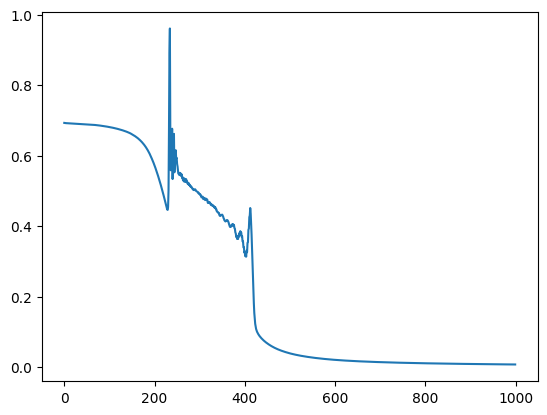

In [82]:
plt.plot(loss_values)
plt.show()

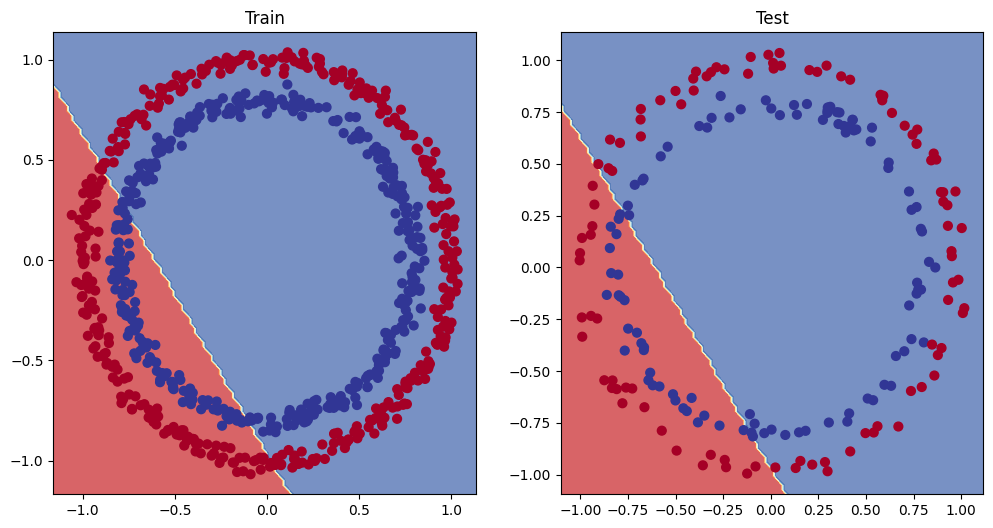

In [83]:
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

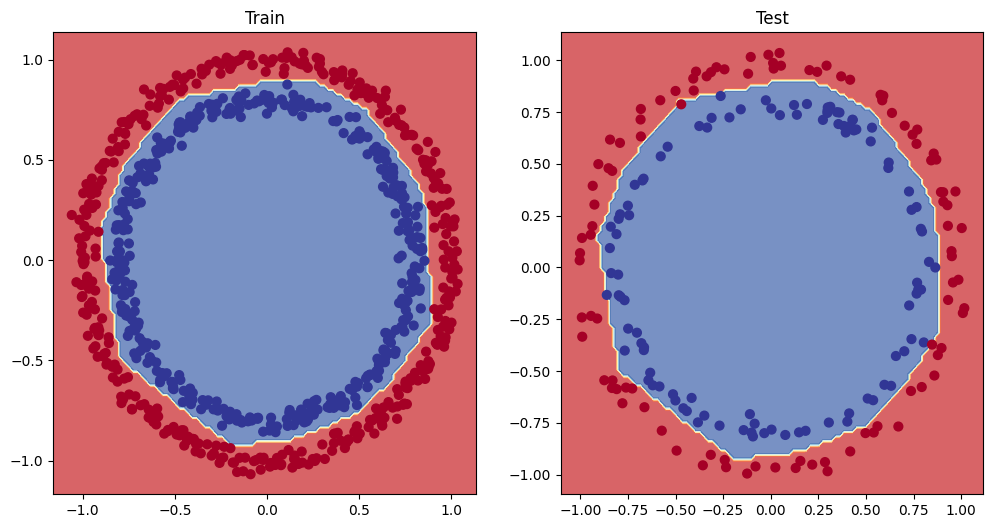

In [84]:
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

In [85]:
model_2 = nn.Sequential(
    nn.Linear(1, 10),
    nn.Linear(10, 10),
    nn.Linear(10, 1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [86]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_2.parameters(),
                            lr=0.1)

In [87]:
# stopped at 11:53

In [88]:
A = torch.arange(-10, 10, 1, dtype=torch.float32)

A.dtype, A.ndim

(torch.float32, 1)

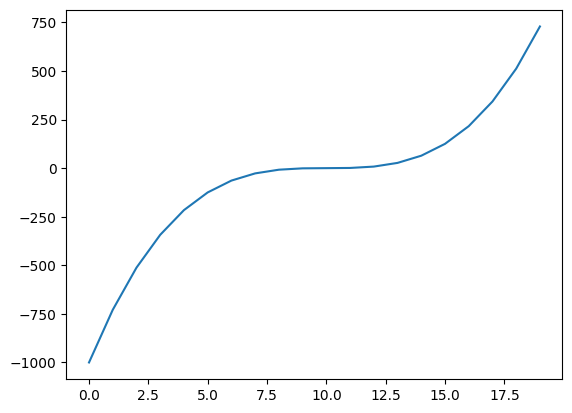

In [89]:
plt.plot(A**3)
plt.show()

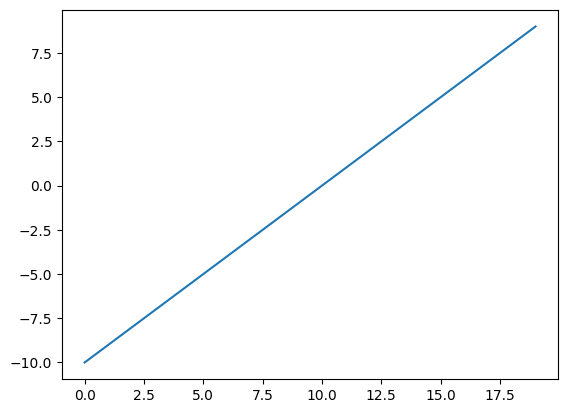

In [90]:
plt.plot(A)
plt.show()

In [91]:
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

In [92]:
def relu(x: torch.Tensor) -> torch.Tensor:
  return torch.maximum(torch.tensor(0), x)

relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

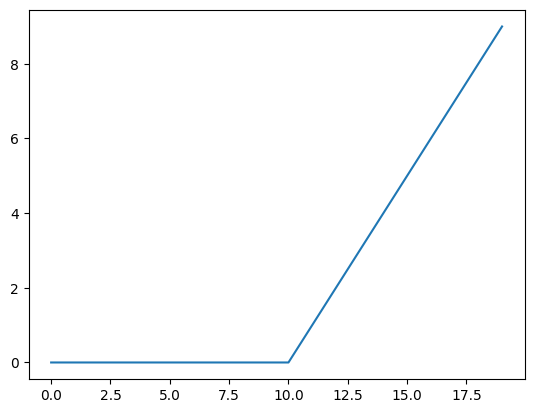

In [93]:
plt.plot(relu(A))
plt.show()

In [94]:
def sigmoid(x: torch.Tensor) -> torch.Tensor:
  return 1 / (1+ torch.exp(-x))

In [95]:
sigmoid(A)

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

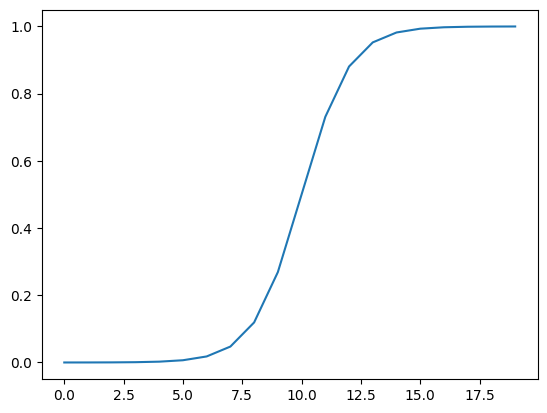

In [96]:
plt.plot(sigmoid(A))
plt.show()

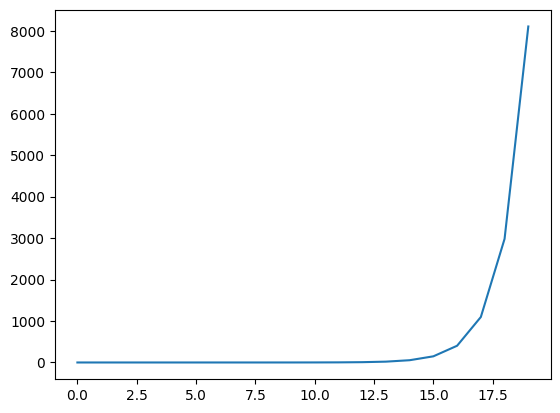

In [97]:
plt.plot(torch.exp(A))

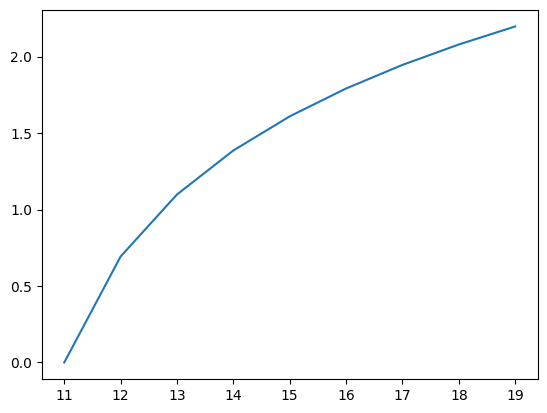

In [98]:
plt.plot(torch.log(A))

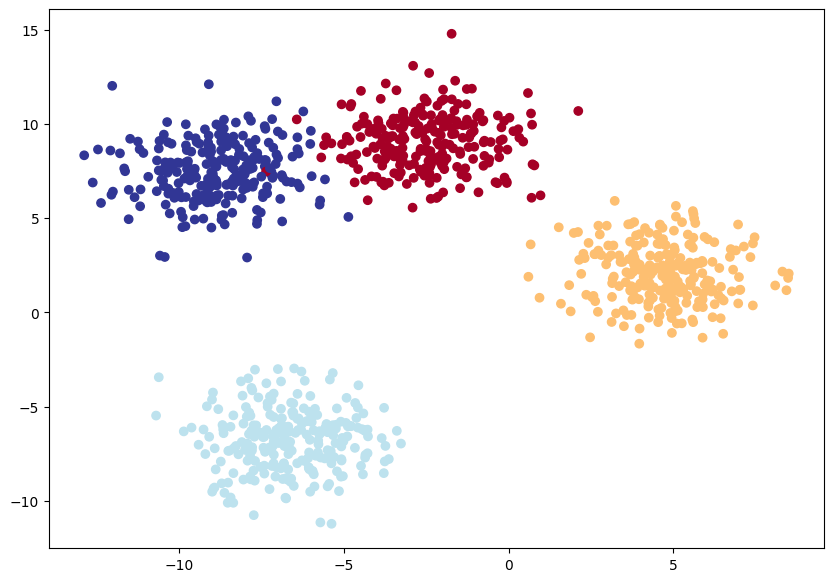

In [122]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split


NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

X_blob, y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURES,
                            centers=NUM_CLASSES,
                            cluster_std=1.5,
                            random_state=RANDOM_SEED)

X_blob = torch.from_numpy(X_blob).type(torch.float32)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size=0.2,
                                                                        random_state=RANDOM_SEED)

plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:,0], X_blob[:, 1],
            c=y_blob,
            cmap=plt.cm.RdYlBu)
plt.show()

In [123]:
X_blob.shape, y_blob.shape

(torch.Size([1000, 2]), torch.Size([1000]))

In [124]:
# stopped at 12:54

In [125]:
len(X_blob_train), len(y_blob_train)

(800, 800)

In [126]:
len(X_blob_test), len(y_blob_test)

(200, 200)

In [127]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [128]:
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=8):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_features)
        )

  def forward(self, x):
    return self.linear_layer_stack(x)


model_4 = BlobModel(input_features=2,
                    output_features=4,
                    hidden_units=8).to(device)

model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [129]:
# stopped at 13:06

In [130]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model_4.parameters(),
                            lr=0.01)

In [131]:
model_4.eval()
with torch.inference_mode():
  y_logits = model_4(X_blob_test.to(device))
y_logits.shape

torch.Size([200, 4])

In [132]:
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[-0.5931, -0.2816, -0.0189, -0.4489],
        [-0.5635, -0.1281,  0.6497,  0.0532],
        [ 0.0471, -0.1494, -0.0637,  0.0524],
        [-0.3913, -0.0431, -0.0270, -0.2189],
        [-0.6505, -0.1699,  0.6013, -0.3917]])
tensor([[0.1888, 0.2578, 0.3353, 0.2181],
        [0.1288, 0.1991, 0.4334, 0.2387],
        [0.2687, 0.2207, 0.2405, 0.2701],
        [0.1982, 0.2808, 0.2854, 0.2355],
        [0.1350, 0.2182, 0.4720, 0.1748]])


In [133]:
torch.sum(y_pred_probs[0])

tensor(1.)

In [134]:
torch.max(y_pred_probs[0])

tensor(0.3353)

In [135]:
torch.argmax(y_pred_probs[0]) # returns the index of the max value, 0-based

tensor(2)

In [136]:
y_pred_probs[0]

tensor([0.1888, 0.2578, 0.3353, 0.2181])

In [137]:
# stopped at 13:23

In [171]:
torch.manual_seed(56)
torch.cuda.manual_seed(56)


epochs = 100

X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
  model_4.train()

  y_logits = model_4(X_blob_train)

  y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

  loss = loss_fn(y_logits, y_blob_train)

  acc = accuracy_fn(y_blob_train, y_pred)

  optimizer.zero_grad()

  loss.backward()
  optimizer.step()

  model_4.eval()
  with torch.inference_mode():
    test_logits = model_4(X_blob_test)
    test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)

    test_loss = loss_fn(test_logits, y_blob_test)
    acc = accuracy_fn(y_blob_test, test_pred)


  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Train Loss: {loss.item():.4f}, Acc: {acc:.2f}% | Test Loss: {test_loss.item():.4f}, Acc: {test_acc:.2f}% ")



Epoch: 0 | Train Loss: 0.0294, Acc: 99.50% | Test Loss: 0.0203, Acc: 99.00% 
Epoch: 10 | Train Loss: 0.0293, Acc: 99.50% | Test Loss: 0.0203, Acc: 99.00% 
Epoch: 20 | Train Loss: 0.0293, Acc: 99.50% | Test Loss: 0.0202, Acc: 99.00% 
Epoch: 30 | Train Loss: 0.0292, Acc: 99.50% | Test Loss: 0.0201, Acc: 99.00% 
Epoch: 40 | Train Loss: 0.0291, Acc: 99.50% | Test Loss: 0.0200, Acc: 99.00% 
Epoch: 50 | Train Loss: 0.0291, Acc: 99.50% | Test Loss: 0.0199, Acc: 99.00% 
Epoch: 60 | Train Loss: 0.0290, Acc: 99.50% | Test Loss: 0.0199, Acc: 99.00% 
Epoch: 70 | Train Loss: 0.0289, Acc: 99.50% | Test Loss: 0.0198, Acc: 99.00% 
Epoch: 80 | Train Loss: 0.0289, Acc: 99.50% | Test Loss: 0.0197, Acc: 99.00% 
Epoch: 90 | Train Loss: 0.0288, Acc: 99.50% | Test Loss: 0.0197, Acc: 99.00% 


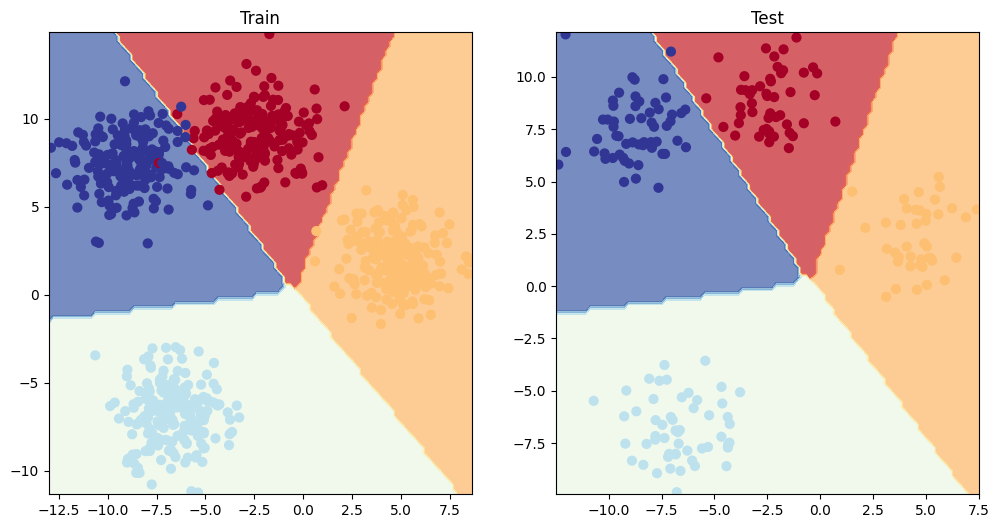

In [178]:
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

In [180]:
# stopped at 14:00